# Tutorial 1: Quickstart Scientific Taste

Estimated time: 20-30 minutes

## Prerequisites
No optional dependencies required.

## Learning aims
- Primary package aim: run `validate -> plan -> run -> runs list/show` on a typed spec
- Secondary scientific aim: relate input perturbations (`a`, `b`) to output behavior (`sum`, `product`)

## Success criteria
- you can explain one observed trend in `sum` and one in `product` from the heatmaps


## Why this tutorial matters
Each step connects CLI execution to scientific reasoning.
You will generate one centralized sweep table and analyze both toy outputs directly from that table.


## Step 1: Validate and plan


In [ ]:
import io
import os
import sys
from contextlib import contextmanager, redirect_stderr, redirect_stdout
from pathlib import Path

root = Path.cwd().resolve()
if not (root / "src").is_dir() and (root.parent / "src").is_dir():
    root = root.parent
if not (root / "src").is_dir():
    raise RuntimeError("Could not locate project root (expected src/).")

src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Jupyter kernels cache imported modules; clear bayesian_metamodeling modules so tutorial
# re-runs always pick up current local source code from src/.
for module_name in list(sys.modules):
    if module_name == "bayesian_metamodeling" or module_name.startswith("bayesian_metamodeling."):
        del sys.modules[module_name]

from bayesian_metamodeling.cli.main import main as mm_main


@contextmanager
def in_project_root():
    previous = Path.cwd()
    os.chdir(root)
    try:
        yield
    finally:
        os.chdir(previous)


def run_mm_cli(*args: str, check: bool = True) -> int:
    stdout_buf = io.StringIO()
    stderr_buf = io.StringIO()
    previous_argv = sys.argv[:]
    try:
        sys.argv = ["mm", *args]
        with in_project_root(), redirect_stdout(stdout_buf), redirect_stderr(stderr_buf):
            exit_code = mm_main()
    finally:
        sys.argv = previous_argv

    print("$ mm", " ".join(args))
    stdout_text = stdout_buf.getvalue().strip()
    stderr_text = stderr_buf.getvalue().strip()
    if stdout_text:
        print(stdout_text)
    if stderr_text:
        print(stderr_text)

    if check and exit_code != 0:
        raise RuntimeError(f"CLI command failed ({exit_code}): mm {' '.join(args)}")
    return exit_code


In [ ]:
SPEC_PATH = "tutorials/specs/model.toy.grid.json"

run_mm_cli("validate", SPEC_PATH)
run_mm_cli("plan", SPEC_PATH)


$ mm validate tutorials/specs/model.toy.grid.json
Spec validation passed: model=toy_program_tutorial, strategy=grid, adapter=python_cli_adapter_v1
$ mm plan tutorials/specs/model.toy.grid.json
Plan points: 9
Preview:
1: {'a': 0.0, 'b': 0.0}
2: {'a': 0.0, 'b': 1.0}
3: {'a': 0.0, 'b': 2.0}
4: {'a': 1.0, 'b': 0.0}
5: {'a': 1.0, 'b': 1.0}


0

## Step 2: Execute sweep and list run IDs


In [ ]:
run_mm_cli("run", SPEC_PATH)
run_mm_cli("runs", "list")


$ mm run tutorials/specs/model.toy.grid.json
Running point 1/9: {'a': 0.0, 'b': 0.0}
Running point 2/9: {'a': 0.0, 'b': 1.0}
Running point 3/9: {'a': 0.0, 'b': 2.0}
Running point 4/9: {'a': 1.0, 'b': 0.0}
Running point 5/9: {'a': 1.0, 'b': 1.0}
Running point 6/9: {'a': 1.0, 'b': 2.0}
Running point 7/9: {'a': 2.0, 'b': 0.0}
Running point 8/9: {'a': 2.0, 'b': 1.0}
Running point 9/9: {'a': 2.0, 'b': 2.0}
Stored sweep run: 981fa6587a5b413c8032d70874910094
Run complete: 9 successful runs
$ mm runs list
Registered runs: 23
- 21dd4b0a11124652ab1ddb03e13e48cc
- 47a04c70f67c446aa96165e0d4361111
- 4d24f876a2184df18d6ca794232cb38e
- 525429e055524e339b275060fb93c2d1
- 5b4395e92a8a47e1a5c3ed4600583d0c
- 5e8bbad6bda4482a96e70998c057c912
- 65ad8179401d413f9992460fa08dadb8
- 804b3b4900f445b0b4e540d52d7816cc
- 8859568360174ad1bafa8490191ab7c7
- 895ec4b3328e4fdf94cffeca955859db
- 8d217ef8174742c28dfb67e146620df6
- 9797f42513904df1ae23b1a37b8608fc
- 981fa6587a5b413c8032d70874910094
- b510e19e1bb443aa850e

0

## Step 3: Auto-select latest toy sweep and inspect run record


In [5]:
import json

registry_path = root / "tmp" / "run_registry.json"


def collect_toy_sweeps() -> list[tuple[str, str, dict]]:
    if not registry_path.exists():
        return []
    registry = json.loads(registry_path.read_text())
    matches: list[tuple[str, str, dict]] = []
    for run_id, record_path in registry.items():
        candidate = Path(record_path)
        if not candidate.is_absolute():
            candidate = root / candidate
        if not candidate.exists():
            continue
        record = json.loads(candidate.read_text())
        sweep_rows_path = record.get("sweep_rows_path", "")
        if sweep_rows_path.startswith("tmp/tutorials/toy_store/sweeps/"):
            matches.append((record.get("finished_at", ""), run_id, record))
    return matches


candidates = collect_toy_sweeps()
if not candidates:
    print("No existing toy sweep found. Running one now...")
    run_mm_cli("run", SPEC_PATH)
    candidates = collect_toy_sweeps()

if not candidates:
    raise RuntimeError("No tutorial toy sweep runs found after attempting execution.")

_, run_id, run_record = sorted(candidates)[-1]
print("Using run id:", run_id)
print("Centralized sweep CSV:", run_record["sweep_rows_path"])
run_mm_cli("runs", "show", run_id, check=False)

sweep_rows_path = root / run_record["sweep_rows_path"]
if not sweep_rows_path.exists():
    raise RuntimeError(f"Sweep CSV does not exist: {sweep_rows_path}")


Using run id: 981fa6587a5b413c8032d70874910094
Centralized sweep CSV: tmp/tutorials/toy_store/sweeps/981fa6587a5b413c8032d70874910094/sweep_rows.csv
$ mm runs show 981fa6587a5b413c8032d70874910094
{
  "adapter_id": "python_cli_adapter_v1",
  "artifact_digest": "a26a5e0db31d0ea7ce9fd9dd1f7a99589a1c109df071c1901fbe2ed92c863d7c",
  "failed_count": 0,
  "finished_at": "2026-02-15T17:10:05.618600+00:00",
  "run_id": "981fa6587a5b413c8032d70874910094",
  "run_type": "sweep",
  "runner_mode": "local_process",
  "seed": 123,
  "spec_digest": "ca34f0e60195e7aaef1730bb25c9341694f19cb70d7672bfbd77be6adbbe0483",
  "started_at": "2026-02-15T17:10:05.222736+00:00",
  "status": "success",
  "success_count": 9,
  "sweep_execution_mode": "serial",
  "sweep_logs_path": "tmp/tutorials/toy_store/sweeps/981fa6587a5b413c8032d70874910094/sweep_logs.jsonl",
  "sweep_manifest_path": "tmp/tutorials/toy_store/sweeps/981fa6587a5b413c8032d70874910094/sweep_manifest.json",
  "sweep_rows_path": "tmp/tutorials/toy_st

## Step 4: Visualize centralized sweep outputs as two heatmaps


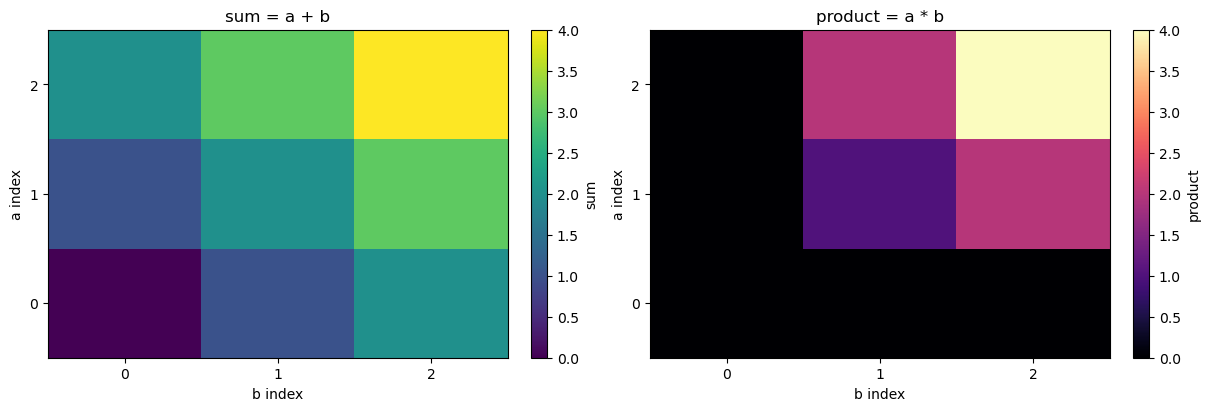

In [6]:
import matplotlib.pyplot as plt

from bayesian_metamodeling.tutorials import load_toy_heatmap_grids

a_vals, b_vals, sum_grid, prod_grid = load_toy_heatmap_grids(sweep_rows_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

im0 = axes[0].imshow(sum_grid, origin="lower", cmap="viridis", aspect="auto")
axes[0].set_title("sum = a + b")
axes[0].set_xlabel("b index")
axes[0].set_ylabel("a index")
axes[0].set_xticks(range(len(b_vals)), labels=[f"{v:g}" for v in b_vals])
axes[0].set_yticks(range(len(a_vals)), labels=[f"{v:g}" for v in a_vals])
fig.colorbar(im0, ax=axes[0], label="sum")

im1 = axes[1].imshow(prod_grid, origin="lower", cmap="magma", aspect="auto")
axes[1].set_title("product = a * b")
axes[1].set_xlabel("b index")
axes[1].set_ylabel("a index")
axes[1].set_xticks(range(len(b_vals)), labels=[f"{v:g}" for v in b_vals])
axes[1].set_yticks(range(len(a_vals)), labels=[f"{v:g}" for v in a_vals])
fig.colorbar(im1, ax=axes[1], label="product")

plt.show()


## Scientific checkpoint
- `sum` heatmap should increase linearly with both `a` and `b`.
- `product` heatmap should be low near zeros and increase fastest when both `a` and `b` are high.

These patterns confirm the toy model equations and show how centralized sweep tables support immediate response-surface analysis.


## Common mistakes
- Running the notebook from the wrong folder without `src/` in scope.
- Forgetting to run Step 2 before attempting sweep visualization.
- Assuming failed rows are included in heatmaps (this tutorial filters to `status == success`).
